In [1]:
pip install deepxde torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.9 MB/s eta 0:00:00


In [3]:
# Cell 1: Imports and Setup
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

dde.config.set_default_float("float64")
print("DeepXDE version:", dde.__version__)

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Set the default float type to float64
DeepXDE version: 1.15.0


In [4]:
# Cell 2: Part A — Heat Equation PINN

def heat_pde(x, y):
    dy_t  = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - 0.4 * dy_xx

def bc_func(x):       return np.zeros((len(x), 1))
def bc_boundary(_, on_boundary): return on_boundary
def ic_func(x):       return np.sin(np.pi * x[:, 0:1])
def ic_initial(_, on_initial):   return on_initial

geom       = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime   = dde.geometry.GeometryXTime(geom, timedomain)

bc = dde.icbc.DirichletBC(geomtime, bc_func, bc_boundary)
ic = dde.icbc.IC(geomtime, ic_func, ic_initial)

data = dde.data.TimePDE(
    geomtime, heat_pde, [bc, ic],
    num_domain=200, num_boundary=50, num_initial=50
)

net = dde.nn.FNN([2] + [10]*2 + [1], "tanh", "Glorot normal")  # 4 layers → 2
model_heat = dde.Model(data, net)

model_heat.compile("adam", lr=1e-3)
losshistory, train_state = model_heat.train(iterations=1000, display_every=200)

print("Training complete.")

Compiling model...
'compile' took 0.036650 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [5.75e-02, 3.09e-02, 7.81e-01]    [5.75e-02, 3.09e-02, 7.81e-01]    []  
200       [1.87e-02, 6.83e-02, 1.33e-01]    [1.87e-02, 6.83e-02, 1.33e-01]    []  
400       [2.38e-02, 4.16e-02, 8.75e-02]    [2.38e-02, 4.16e-02, 8.75e-02]    []  
600       [1.50e-02, 3.02e-02, 5.82e-02]    [1.50e-02, 3.02e-02, 5.82e-02]    []  
800       [1.08e-02, 2.49e-02, 3.92e-02]    [1.08e-02, 2.49e-02, 3.92e-02]    []  
1000      [9.50e-03, 1.98e-02, 2.88e-02]    [9.50e-03, 1.98e-02, 2.88e-02]    []  

Best model at step 1000:
  train loss: 5.82e-02
  test loss: 5.82e-02
  test metric: []

'train' took 6.212437 s

Training complete.


L² relative error (Part A): 3.3844e-01


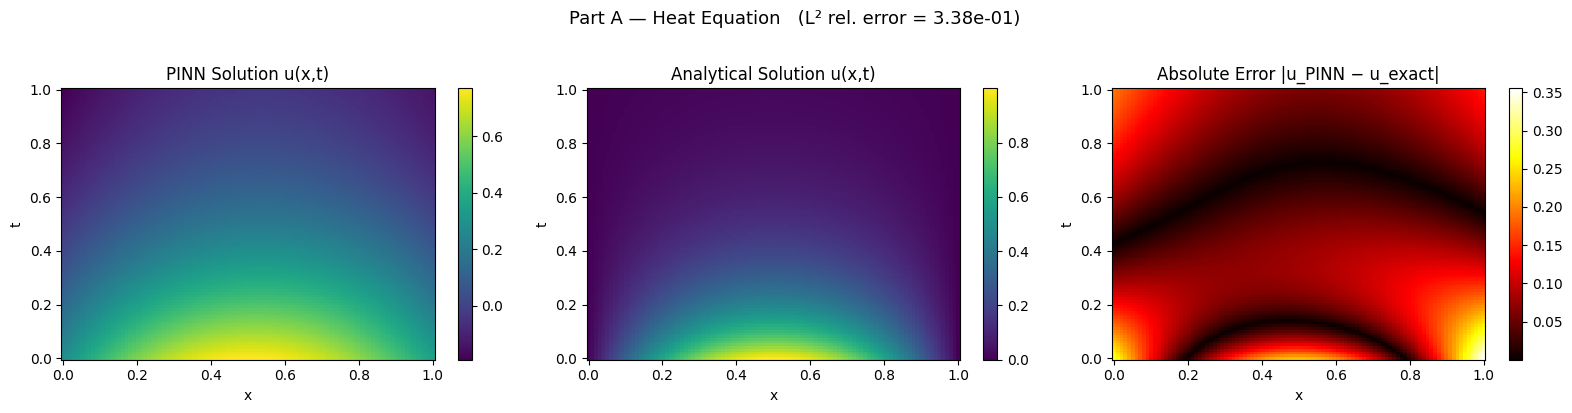

In [6]:
# Cell 3: Part A — Evaluate and visualize

# Dense evaluation grid
nx, nt = 100, 100
x_vals = np.linspace(0, 1, nx)
t_vals = np.linspace(0, 1, nt)
X, T   = np.meshgrid(x_vals, t_vals)          # shape (nt, nx)
XT     = np.column_stack([X.ravel(), T.ravel()])  # shape (nt*nx, 2)

# PINN prediction
u_pinn = model_heat.predict(XT).reshape(nt, nx)

# Analytical solution: u = exp(-0.4 π² t) sin(πx)
u_exact = np.exp(-0.4 * np.pi**2 * T) * np.sin(np.pi * X)

# Absolute error
u_error = np.abs(u_pinn - u_exact)

# L² relative error
l2_err = np.linalg.norm(u_pinn - u_exact) / np.linalg.norm(u_exact)
print(f"L² relative error (Part A): {l2_err:.4e}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

titles  = ["PINN Solution u(x,t)", "Analytical Solution u(x,t)", "Absolute Error |u_PINN − u_exact|"]
fields  = [u_pinn, u_exact, u_error]
cmaps   = ["viridis", "viridis", "hot"]

for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    im = ax.pcolormesh(x_vals, t_vals, field, cmap=cmap, shading="auto")
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.set_title(title)

plt.suptitle(f"Part A — Heat Equation   (L² rel. error = {l2_err:.2e})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4: Part B — Collocation Sampling Experiment
# Tests num_domain in [500, 1000, 2500, 5000, 10000]

collocation_counts = [500, 1000, 2500, 5000, 10000]
l2_errors = []

for n_domain in collocation_counts:
    print(f"\n▶  num_domain = {n_domain}")
    dde.config.set_default_float("float64")

    # Rebuild everything fresh for each run
    geom_b       = dde.geometry.Interval(0, 1)
    tdom_b       = dde.geometry.TimeDomain(0, 1)
    geomtime_b   = dde.geometry.GeometryXTime(geom_b, tdom_b)

    bc_b = dde.icbc.DirichletBC(
        geomtime_b, lambda x: np.zeros((len(x), 1)),
        lambda _, on_boundary: on_boundary
    )
    ic_b = dde.icbc.IC(
        geomtime_b, lambda x: np.sin(np.pi * x[:, 0:1]),
        lambda _, on_initial: on_initial
    )

    data_b = dde.data.TimePDE(
        geomtime_b, heat_pde, [bc_b, ic_b],
        num_domain=n_domain, num_boundary=200, num_initial=200
    )
    net_b   = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
    model_b = dde.Model(data_b, net_b)

    model_b.compile("adam", lr=1e-3)
    model_b.train(iterations=8000, display_every=8000)
    model_b.compile("L-BFGS")
    model_b.train(display_every=1000)

    u_pred = model_b.predict(XT).reshape(nt, nx)
    err    = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    l2_errors.append(err)
    print(f"   L² rel. error = {err:.4e}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(collocation_counts, l2_errors, "o-", color="steelblue", lw=2, markersize=7)
for n, e in zip(collocation_counts, l2_errors):
    ax.annotate(f"{e:.1e}", (n, e), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Number of collocation points (num_domain)")
ax.set_ylabel("L² relative error")
ax.set_title("Part B — Collocation Sampling Experiment")
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


▶  num_domain = 500
Set the default float type to float64
Compiling model...
'compile' took 0.003183 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [3.03e-03, 8.19e-02, 2.93e-01]    [3.03e-03, 8.19e-02, 2.93e-01]    []  
8000      [4.28e-04, 9.01e-05, 3.44e-05]    [4.28e-04, 9.01e-05, 3.44e-05]    []  

Best model at step 8000:
  train loss: 5.52e-04
  test loss: 5.52e-04
  test metric: []

'train' took 431.668218 s

Compiling model...
'compile' took 0.006647 s

Training model...

Step      Train loss                        Test loss                         Test metric
8000      [4.28e-04, 9.01e-05, 3.44e-05]    [4.28e-04, 9.01e-05, 3.44e-05]    []  


In [ ]:
# Cell 5: Part C — Wave Equation PINN

def wave_pde(x, y):
    """Residual of  u_tt - u_xx = 0  (c=1)"""
    dy_tt = dde.grad.hessian(y, x, i=1, j=1)   # ∂²u/∂t²
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)   # ∂²u/∂x²
    return dy_tt - dy_xx

geom_w     = dde.geometry.Interval(0, 1)
tdom_w     = dde.geometry.TimeDomain(0, 1)
geomtime_w = dde.geometry.GeometryXTime(geom_w, tdom_w)

# Dirichlet BCs: u(0,t)=0, u(1,t)=0
bc_w = dde.icbc.DirichletBC(
    geomtime_w, lambda x: np.zeros((len(x), 1)),
    lambda _, on_boundary: on_boundary
)

# IC 1: u(x,0) = sin(πx)
ic_w1 = dde.icbc.IC(
    geomtime_w, lambda x: np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

# IC 2: u_t(x,0) = 0  — use OperatorBC on the time-derivative
def ic_deriv(x, y, X):
    """Enforce ∂u/∂t = 0 at t = 0"""
    return dde.grad.jacobian(y, x, i=0, j=1)   # ∂u/∂t

ic_w2 = dde.icbc.OperatorBC(
    geomtime_w,
    ic_deriv,
    lambda x, on_initial: on_initial
)

data_w = dde.data.TimePDE(
    geomtime_w, wave_pde, [bc_w, ic_w1, ic_w2],
    num_domain=4000, num_boundary=400, num_initial=400
)
net_w   = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model_w = dde.Model(data_w, net_w)

model_w.compile("adam", lr=1e-3)
model_w.train(iterations=15000, display_every=3000)
model_w.compile("L-BFGS")
model_w.train()

print("Wave equation training complete.")

In [ ]:
# Cell 6: Part C — Plot wave solution and compare with heat equation

u_wave = model_w.predict(XT).reshape(nt, nx)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].pcolormesh(x_vals, t_vals, u_pinn, cmap="viridis", shading="auto")
plt.colorbar(im0, ax=axes[0])
axes[0].set_title("Heat Equation — PINN solution")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")

im1 = axes[1].pcolormesh(x_vals, t_vals, u_wave, cmap="RdBu_r", shading="auto")
plt.colorbar(im1, ax=axes[1])
axes[1].set_title("Wave Equation — PINN solution")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")

plt.suptitle("Part C — Heat vs Wave: qualitative comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Snapshot comparison at t = 0.5
fig2, ax2 = plt.subplots(figsize=(7, 4))
t_idx = nt // 2   # t ≈ 0.5
ax2.plot(x_vals, u_pinn[t_idx], label="Heat eq. (t=0.5)", lw=2)
ax2.plot(x_vals, u_wave[t_idx], label="Wave eq. (t=0.5)", lw=2, ls="--")
ax2.axhline(0, color="k", lw=0.5)
ax2.set_xlabel("x"); ax2.set_ylabel("u(x, 0.5)")
ax2.set_title("Snapshot at t = 0.5: Heat vs Wave")
ax2.legend(); ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()